# 03. Item & Category Analysis

이 노트북은 `events_clean`과 `item_latest_category`를 연결하여 상품 및 카테고리 단위 전환 성과를 분석한다.

핵심 질문은 다음과 같다.

- 어떤 상품이 가장 많이 조회되고, 장바구니에 담기고, 구매되었는가?
- 조회 수가 많은 상품 중 구매 전환이 낮은 상품은 무엇인가?
- 조회 수는 상대적으로 작지만 구매 효율이 높은 상품은 무엇인가?
- 어떤 카테고리가 `View → Add to Cart`, `View → Purchase` 전환을 잘 만들었는가?
- A/B Test 설계 관점에서 우선 개선해야 할 상품/카테고리 영역은 어디인가?

이 노트북의 결과는 이후 `04_ab_test_design_simulation.ipynb`와 Streamlit 대시보드의 `Item & Category Insights` 페이지로 연결된다.

In [1]:
# ============================================================
# 0. Library Setting
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.1.3


In [2]:
# ============================================================
# 1. Project Path Setting
# ============================================================

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
TABLE_DIR = OUTPUT_DIR / "tables"

for path in [PROCESSED_DIR, OUTPUT_DIR, CHART_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

EVENTS_PARQUET_PATH = PROCESSED_DIR / "events_clean.parquet"
EVENTS_CSV_PATH = PROCESSED_DIR / "events_clean.csv"

ITEM_CATEGORY_PARQUET_PATH = PROCESSED_DIR / "item_latest_category.parquet"
ITEM_CATEGORY_CSV_PATH = PROCESSED_DIR / "item_latest_category.csv"

CATEGORY_TREE_PATH = RAW_DIR / "category_tree.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("events parquet exists:", EVENTS_PARQUET_PATH.exists())
print("events csv exists:", EVENTS_CSV_PATH.exists())
print("item category parquet exists:", ITEM_CATEGORY_PARQUET_PATH.exists())
print("item category csv exists:", ITEM_CATEGORY_CSV_PATH.exists())
print("category tree exists:", CATEGORY_TREE_PATH.exists())

PROJECT_ROOT: c:\Users\USER\Desktop\ecommerce_ab_test_project
events parquet exists: False
events csv exists: True
item category parquet exists: False
item category csv exists: True
category tree exists: True


In [3]:
# ============================================================
# 2. Utility Functions
# ============================================================

def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> Path:
    """분석 결과 테이블을 outputs/tables에 저장한다."""
    save_path = TABLE_DIR / filename
    df.to_csv(save_path, index=index, encoding="utf-8-sig")
    print(f"saved: {save_path}")
    return save_path


def save_chart(filename: str) -> Path:
    """현재 matplotlib figure를 outputs/charts에 저장한다."""
    save_path = CHART_DIR / filename
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"saved: {save_path}")
    return save_path


def read_processed_data(parquet_path: Path, csv_path: Path, name: str) -> pd.DataFrame:
    """parquet 우선, csv fallback 방식으로 processed 데이터를 읽는다."""
    if parquet_path.exists():
        print(f"loading {name} from parquet:", parquet_path)
        return pd.read_parquet(parquet_path)

    if csv_path.exists():
        print(f"loading {name} from csv:", csv_path)
        return pd.read_csv(csv_path)

    raise FileNotFoundError(f"{name} 파일을 찾을 수 없습니다: {parquet_path} 또는 {csv_path}")


def safe_divide(numerator, denominator):
    """0으로 나누는 상황을 방지한 비율 계산."""
    return np.where(denominator > 0, numerator / denominator, np.nan)


def add_bar_labels(ax, values, fmt="{:,.0f}"):
    """막대그래프 위에 값 라벨을 추가한다."""
    for i, v in enumerate(values):
        ax.text(i, v, fmt.format(v), ha="center", va="bottom", fontsize=9)


def classify_opportunity(row):
    """조회량과 구매전환율을 기준으로 상품/카테고리 기회 유형을 분류한다."""
    high_traffic = row["traffic_level"] == "High traffic"
    high_conversion = row["conversion_level"] == "High conversion"

    if high_traffic and high_conversion:
        return "Star: high traffic & high conversion"
    if high_traffic and not high_conversion:
        return "Optimization: high traffic & low conversion"
    if not high_traffic and high_conversion:
        return "Expansion: low traffic & high conversion"
    return "Long-tail: low traffic & low conversion"

## 1. Load Processed Data

`01_raw_data_audit.ipynb`에서 생성한 processed layer를 사용한다.

- `events_clean`: 행동 로그 데이터
- `item_latest_category`: item별 최신 category 매핑
- `category_tree`: 카테고리 계층 구조

In [4]:
# ============================================================
# 3. Load Data
# ============================================================

events = read_processed_data(
    EVENTS_PARQUET_PATH,
    EVENTS_CSV_PATH,
    "events_clean",
)

item_latest_category = read_processed_data(
    ITEM_CATEGORY_PARQUET_PATH,
    ITEM_CATEGORY_CSV_PATH,
    "item_latest_category",
)

if CATEGORY_TREE_PATH.exists():
    category_tree = pd.read_csv(CATEGORY_TREE_PATH)
else:
    category_tree = pd.DataFrame(columns=["categoryid", "parentid"])

print("events shape:", events.shape)
print("item_latest_category shape:", item_latest_category.shape)
print("category_tree shape:", category_tree.shape)

display(events.head())
display(item_latest_category.head())
display(category_tree.head())

loading events_clean from csv: c:\Users\USER\Desktop\ecommerce_ab_test_project\data\processed\events_clean.csv
loading item_latest_category from csv: c:\Users\USER\Desktop\ecommerce_ab_test_project\data\processed\item_latest_category.csv
events shape: (2756101, 8)
item_latest_category shape: (417053, 5)
category_tree shape: (1669, 2)


,timestamp,visitorid,event,itemid,transactionid,event_time,event_date,event_month
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117,2015-06-02,2015-06
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164,2015-06-02,2015-06
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827,2015-06-02,2015-06
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914,2015-06-02,2015-06
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106,2015-06-02,2015-06


,itemid,categoryid,timestamp,property_time,source_file
0,0,209,1431226800000,2015-05-10 03:00:00,item_properties_part2.csv
1,1,1114,1431226800000,2015-05-10 03:00:00,item_properties_part1.csv
2,2,1305,1431226800000,2015-05-10 03:00:00,item_properties_part1.csv
3,3,1171,1433041200000,2015-05-31 03:00:00,item_properties_part1.csv
4,4,1038,1431831600000,2015-05-17 03:00:00,item_properties_part2.csv


,categoryid,parentid
0,1016,213.0000
1,809,169.0000
2,570,9.0000
3,1691,885.0000
4,536,"1,691.0000"


In [5]:
# ============================================================
# 4. Type Validation
# ============================================================

events["event"] = events["event"].astype("category")

if "event_time" in events.columns:
    events["event_time"] = pd.to_datetime(events["event_time"])
else:
    events["event_time"] = pd.to_datetime(events["timestamp"], unit="ms")

if "event_date" not in events.columns:
    events["event_date"] = events["event_time"].dt.date
else:
    events["event_date"] = pd.to_datetime(events["event_date"]).dt.date

if "event_month" not in events.columns:
    events["event_month"] = events["event_time"].dt.to_period("M").astype(str)

item_latest_category["itemid"] = item_latest_category["itemid"].astype("int64")
item_latest_category["categoryid"] = item_latest_category["categoryid"].astype("int64")

if "categoryid" in category_tree.columns:
    category_tree["categoryid"] = category_tree["categoryid"].astype("int64")

if "parentid" in category_tree.columns:
    category_tree["parentid"] = pd.to_numeric(category_tree["parentid"], errors="coerce")

print("events dtypes")
display(events.dtypes)

print("item_latest_category dtypes")
display(item_latest_category.dtypes)

events dtypes


timestamp                 int64
visitorid                 int64
event                  category
itemid                    int64
transactionid           float64
event_time       datetime64[ns]
event_date               object
event_month              object
dtype: object

item_latest_category dtypes


itemid            int64
categoryid        int64
timestamp         int64
property_time    object
source_file      object
dtype: object

## 2. Event Data와 Category Mapping 연결성 점검

분석 전, 행동 로그의 상품들이 category 정보와 얼마나 연결되는지 확인한다.

카테고리 연결률이 충분히 높으면 카테고리 기반 전환 분석을 진행할 수 있다.

In [6]:
# ============================================================
# 5. Merge Events with Item Category
# ============================================================

events_with_category = events.merge(
    item_latest_category[["itemid", "categoryid"]],
    on="itemid",
    how="left",
)

category_coverage = pd.DataFrame([
    {
        "metric": "event_rows",
        "value": len(events_with_category),
    },
    {
        "metric": "event_rows_with_category",
        "value": int(events_with_category["categoryid"].notna().sum()),
    },
    {
        "metric": "event_row_category_coverage_rate",
        "value": float(events_with_category["categoryid"].notna().mean()),
    },
    {
        "metric": "unique_items_in_events",
        "value": int(events_with_category["itemid"].nunique()),
    },
    {
        "metric": "unique_items_with_category_in_events",
        "value": int(events_with_category.loc[events_with_category["categoryid"].notna(), "itemid"].nunique()),
    },
    {
        "metric": "item_category_coverage_rate",
        "value": float(
            events_with_category.loc[events_with_category["categoryid"].notna(), "itemid"].nunique()
            / events_with_category["itemid"].nunique()
        ),
    },
])

display(category_coverage)
save_table(category_coverage, "03_category_coverage_summary.csv")

,metric,value
0,event_rows,"2,756,101.0000"
1,event_rows_with_category,"2,500,516.0000"
2,event_row_category_coverage_rate,0.9073
3,unique_items_in_events,"235,061.0000"
4,unique_items_with_category_in_events,"185,246.0000"
5,item_category_coverage_rate,0.7881


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_category_coverage_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/03_category_coverage_summary.csv')

In [7]:
# ============================================================
# 6. Category Tree Enrichment
# ============================================================

if not category_tree.empty:
    category_tree_enriched = category_tree.copy()
    category_tree_enriched = category_tree_enriched.rename(columns={"parentid": "parent_categoryid"})

    events_with_category = events_with_category.merge(
        category_tree_enriched[["categoryid", "parent_categoryid"]],
        on="categoryid",
        how="left",
    )

    events_with_category["is_root_category"] = events_with_category["parent_categoryid"].isna()
else:
    events_with_category["parent_categoryid"] = np.nan
    events_with_category["is_root_category"] = np.nan

print("events_with_category shape:", events_with_category.shape)
display(events_with_category.head())

events_with_category shape: (2756101, 11)


,timestamp,visitorid,event,itemid,transactionid,event_time,event_date,event_month,categoryid,parent_categoryid,is_root_category
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117,2015-06-02,2015-06,"1,173.0000",805.0000,False
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164,2015-06-02,2015-06,"1,231.0000",901.0000,False
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827,2015-06-02,2015-06,NaN,NaN,True
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914,2015-06-02,2015-06,914.0000,226.0000,False
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106,2015-06-02,2015-06,491.0000,679.0000,False


## 3. Item-Level Performance

상품 단위로 조회, 장바구니, 구매 이벤트를 집계한다.

단순히 많이 팔린 상품뿐 아니라 다음과 같은 관점에서 본다.

- 트래픽이 높은 상품
- 구매가 많이 발생한 상품
- 조회 대비 장바구니 전환이 높은 상품
- 조회 대비 구매 전환이 높은 상품
- 조회는 많지만 구매 전환이 낮은 개선 대상 상품

In [8]:
# ============================================================
# 7. Item-Level Event Counts
# ============================================================

item_event_counts = (
    events_with_category
    .pivot_table(
        index=["itemid"],
        columns="event",
        values="visitorid",
        aggfunc="count",
        fill_value=0,
        observed=False,
    )
    .reset_index()
)

for col in ["view", "addtocart", "transaction"]:
    if col not in item_event_counts.columns:
        item_event_counts[col] = 0

item_event_counts = item_event_counts[["itemid", "view", "addtocart", "transaction"]]

item_event_counts = item_event_counts.rename(columns={
    "view": "view_events",
    "addtocart": "cart_events",
    "transaction": "purchase_events",
})

item_unique_users = (
    events_with_category
    .groupby(["itemid", "event"], observed=False)["visitorid"]
    .nunique()
    .reset_index(name="unique_visitors")
    .pivot(index="itemid", columns="event", values="unique_visitors")
    .fillna(0)
    .reset_index()
)

for col in ["view", "addtocart", "transaction"]:
    if col not in item_unique_users.columns:
        item_unique_users[col] = 0

item_unique_users = item_unique_users[["itemid", "view", "addtocart", "transaction"]]

item_unique_users = item_unique_users.rename(columns={
    "view": "view_users",
    "addtocart": "cart_users",
    "transaction": "purchase_users",
})

item_performance = item_event_counts.merge(
    item_unique_users,
    on="itemid",
    how="left",
)

item_performance = item_performance.merge(
    item_latest_category[["itemid", "categoryid"]],
    on="itemid",
    how="left",
)

item_performance["view_to_cart_rate"] = safe_divide(
    item_performance["cart_users"],
    item_performance["view_users"],
)

item_performance["cart_to_purchase_rate"] = safe_divide(
    item_performance["purchase_users"],
    item_performance["cart_users"],
)

item_performance["view_to_purchase_rate"] = safe_divide(
    item_performance["purchase_users"],
    item_performance["view_users"],
)

item_performance["purchase_events_per_view_event"] = safe_divide(
    item_performance["purchase_events"],
    item_performance["view_events"],
)

item_performance["cart_events_per_view_event"] = safe_divide(
    item_performance["cart_events"],
    item_performance["view_events"],
)

item_performance = item_performance.sort_values(
    ["purchase_users", "view_to_purchase_rate", "view_users"],
    ascending=[False, False, False],
)

print("item_performance shape:", item_performance.shape)
display(item_performance.head(20))

save_table(item_performance, "03_item_performance_full.csv")

item_performance shape: (235061, 13)


,itemid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
232496,461686,2539,306,133,1379,267,129,"1,037.0000",0.1936,0.4831,0.0935,0.0524,0.1205
107690,213834,293,17,92,199,17,80,"1,163.0000",0.0854,4.7059,0.4020,0.3140,0.0580
3980,7943,1346,97,46,843,87,46,398.0000,0.1032,0.5287,0.0546,0.0342,0.0721
60527,119736,752,44,97,251,30,42,57.0000,0.1195,1.4000,0.1673,0.1290,0.0585
224330,445351,939,89,45,618,80,42,"1,483.0000",0.1294,0.5250,0.0680,0.0479,0.0948
24339,48030,986,95,41,628,85,38,"1,219.0000",0.1354,0.4471,0.0605,0.0416,0.0963
157492,312728,947,162,46,602,129,37,"1,098.0000",0.2143,0.2868,0.0615,0.0486,0.1711
212061,420960,796,60,38,371,55,36,"1,529.0000",0.1482,0.6545,0.0970,0.0477,0.0754
8763,17478,631,72,37,378,65,35,"1,373.0000",0.1720,0.5385,0.0926,0.0586,0.1141
209597,416017,393,49,32,186,45,32,"1,103.0000",0.2419,0.7111,0.1720,0.0814,0.1247


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_item_performance_full.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/03_item_performance_full.csv')

In [9]:
# ============================================================
# 8. Item-Level Summary Statistics
# ============================================================

item_performance_summary = (
    item_performance[
        [
            "view_events",
            "cart_events",
            "purchase_events",
            "view_users",
            "cart_users",
            "purchase_users",
            "view_to_cart_rate",
            "cart_to_purchase_rate",
            "view_to_purchase_rate",
        ]
    ]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

display(item_performance_summary)
save_table(item_performance_summary, "03_item_performance_summary_stats.csv")

,metric,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
0,view_events,"235,061.0000",11.3346,35.3943,0.0000,1.0000,3.0000,9.0000,25.0000,46.0000,138.0000,"3,410.0000"
1,cart_events,"235,061.0000",0.2950,1.8268,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,6.0000,306.0000
2,purchase_events,"235,061.0000",0.0955,0.7383,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,133.0000
3,view_users,"235,061.0000",9.0705,26.9245,0.0000,1.0000,2.0000,7.0000,20.0000,36.0000,104.0000,"2,911.0000"
4,cart_users,"235,061.0000",0.2639,1.5838,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,5.0000,267.0000
5,purchase_users,"235,061.0000",0.0905,0.6680,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,129.0000
6,view_to_cart_rate,"234,838.0000",0.0152,0.0767,0.0000,0.0000,0.0000,0.0000,0.0104,0.0909,0.3333,3.0000
7,cart_to_purchase_rate,"23,903.0000",0.3237,0.4068,0.0000,0.0000,0.0000,0.5000,1.0000,1.0000,1.0000,4.7059
8,view_to_purchase_rate,"234,838.0000",0.0044,0.0329,0.0000,0.0000,0.0000,0.0000,0.0000,0.0075,0.1200,2.0000


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_item_performance_summary_stats.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/03_item_performance_summary_stats.csv')

In [10]:
# ============================================================
# 9. Top Items by Traffic, Cart, Purchase
# ============================================================

TOP_N = 20

top_items_by_views = (
    item_performance
    .sort_values(["view_users", "view_events"], ascending=[False, False])
    .head(TOP_N)
)

top_items_by_cart = (
    item_performance
    .sort_values(["cart_users", "cart_events"], ascending=[False, False])
    .head(TOP_N)
)

top_items_by_purchase = (
    item_performance
    .sort_values(["purchase_users", "purchase_events"], ascending=[False, False])
    .head(TOP_N)
)

display(top_items_by_views)
display(top_items_by_cart)
display(top_items_by_purchase)

save_table(top_items_by_views, "03_top_items_by_views.csv")
save_table(top_items_by_cart, "03_top_items_by_cart.csv")
save_table(top_items_by_purchase, "03_top_items_by_purchase.csv")

,itemid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
94720,187946,3410,2,0,2911,2,0,"1,393.0000",0.0007,0.0000,0.0000,0.0000,0.0006
2719,5411,2325,9,0,2078,9,0,789.0000,0.0043,0.0000,0.0000,0.0000,0.0039
186716,370653,1854,0,0,1577,0,0,82.0000,0.0000,NaN,0.0000,0.0000,0.0000
232496,461686,2539,306,133,1379,267,129,"1,037.0000",0.1936,0.4831,0.0935,0.0524,0.1205
49024,96924,1633,0,0,1359,0,0,56.0000,0.0000,NaN,0.0000,0.0000,0.0000
110536,219512,1740,48,12,1358,47,12,5.0000,0.0346,0.2553,0.0088,0.0069,0.0276
150148,298009,1642,0,0,1342,0,0,529.0000,0.0000,NaN,0.0000,0.0000,0.0000
169261,335975,1428,0,0,1154,0,0,48.0000,0.0000,NaN,0.0000,0.0000,0.0000
193605,384302,1528,65,15,1143,55,14,5.0000,0.0481,0.2545,0.0122,0.0098,0.0425
76432,151444,1230,0,0,1103,0,0,656.0000,0.0000,NaN,0.0000,0.0000,0.0000


,itemid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
232496,461686,2539,306,133,1379,267,129,"1,037.0000",0.1936,0.4831,0.0935,0.0524,0.1205
161235,320130,1333,141,33,846,131,27,"1,483.0000",0.1548,0.2061,0.0319,0.0248,0.1058
157492,312728,947,162,46,602,129,37,"1,098.0000",0.2143,0.2868,0.0615,0.0486,0.1711
206467,409804,647,156,35,453,128,30,"1,191.0000",0.2826,0.2344,0.0662,0.0541,0.2411
14707,29196,912,136,19,624,101,19,"1,265.0000",0.1619,0.1881,0.0304,0.0208,0.1491
3980,7943,1346,97,46,843,87,46,398.0000,0.1032,0.5287,0.0546,0.0342,0.0721
24339,48030,986,95,41,628,85,38,"1,219.0000",0.1354,0.4471,0.0605,0.0416,0.0963
222558,441852,860,90,27,625,82,23,959.0000,0.1312,0.2805,0.0368,0.0314,0.1047
224330,445351,939,89,45,618,80,42,"1,483.0000",0.1294,0.5250,0.0680,0.0479,0.0948
129504,257040,1531,89,27,979,79,24,683.0000,0.0807,0.3038,0.0245,0.0176,0.0581


,itemid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
232496,461686,2539,306,133,1379,267,129,"1,037.0000",0.1936,0.4831,0.0935,0.0524,0.1205
107690,213834,293,17,92,199,17,80,"1,163.0000",0.0854,4.7059,0.4020,0.3140,0.0580
3980,7943,1346,97,46,843,87,46,398.0000,0.1032,0.5287,0.0546,0.0342,0.0721
60527,119736,752,44,97,251,30,42,57.0000,0.1195,1.4000,0.1673,0.1290,0.0585
224330,445351,939,89,45,618,80,42,"1,483.0000",0.1294,0.5250,0.0680,0.0479,0.0948
24339,48030,986,95,41,628,85,38,"1,219.0000",0.1354,0.4471,0.0605,0.0416,0.0963
157492,312728,947,162,46,602,129,37,"1,098.0000",0.2143,0.2868,0.0615,0.0486,0.1711
212061,420960,796,60,38,371,55,36,"1,529.0000",0.1482,0.6545,0.0970,0.0477,0.0754
8763,17478,631,72,37,378,65,35,"1,373.0000",0.1720,0.5385,0.0926,0.0586,0.1141
209597,416017,393,49,32,186,45,32,"1,103.0000",0.2419,0.7111,0.1720,0.0814,0.1247


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_top_items_by_views.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_top_items_by_cart.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_top_items_by_purchase.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/03_top_items_by_purchase.csv')

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\03_top_items_by_view_users.png


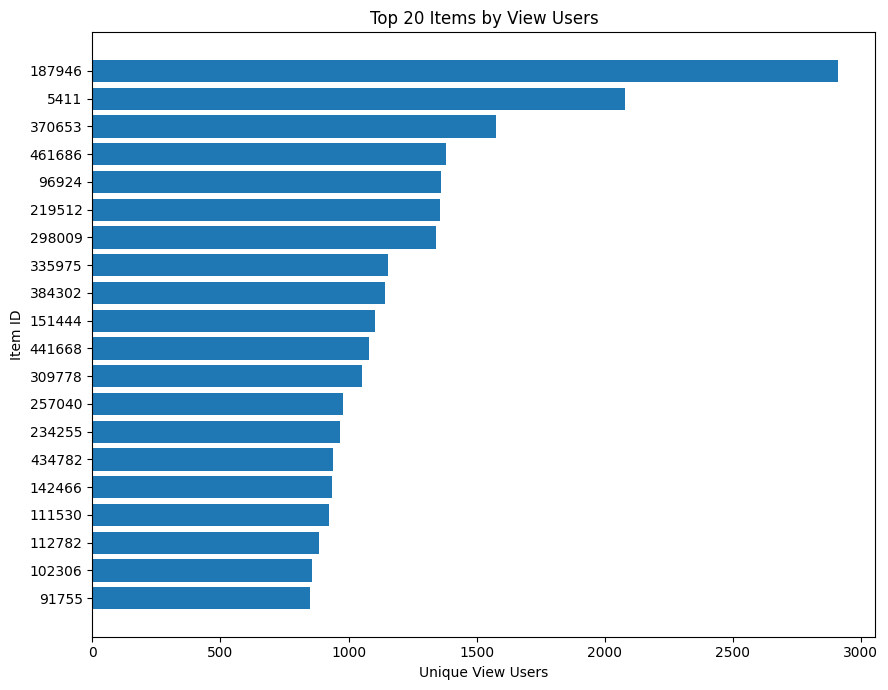

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\03_top_items_by_purchase_users.png


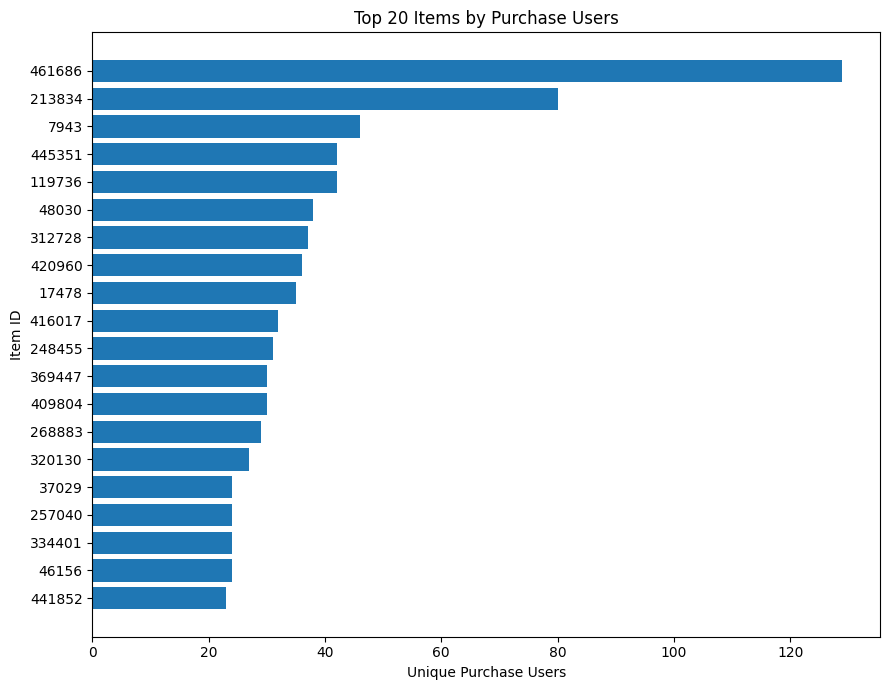

In [11]:
# ============================================================
# 10. Top Items Chart
# ============================================================

plot_df = top_items_by_views.sort_values("view_users", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(plot_df["itemid"].astype(str), plot_df["view_users"])
plt.title("Top 20 Items by View Users")
plt.xlabel("Unique View Users")
plt.ylabel("Item ID")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()

save_chart("03_top_items_by_view_users.png")
plt.show()


plot_df = top_items_by_purchase.sort_values("purchase_users", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(plot_df["itemid"].astype(str), plot_df["purchase_users"])
plt.title("Top 20 Items by Purchase Users")
plt.xlabel("Unique Purchase Users")
plt.ylabel("Item ID")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()

save_chart("03_top_items_by_purchase_users.png")
plt.show()

## 4. Item-Level Conversion Quality

전환율만 단순 비교하면 조회 수가 극히 적은 상품이 과대평가될 수 있다.

따라서 최소 조회 사용자 수 기준을 둔다.

- `min_view_users_item`: 상품 단위 전환율 분석에 포함할 최소 조회 사용자 수
- 기본값은 100명으로 설정
- 데이터 크기와 해석 목적에 따라 조정 가능

In [12]:
# ============================================================
# 11. High-Conversion and Low-Conversion Items
# ============================================================

min_view_users_item = 100

eligible_items = item_performance.loc[
    item_performance["view_users"] >= min_view_users_item
].copy()

high_conversion_items = (
    eligible_items
    .sort_values(["view_to_purchase_rate", "purchase_users", "view_users"], ascending=[False, False, False])
    .head(30)
)

high_cart_conversion_items = (
    eligible_items
    .sort_values(["view_to_cart_rate", "cart_users", "view_users"], ascending=[False, False, False])
    .head(30)
)

high_traffic_low_purchase_items = (
    eligible_items
    .loc[eligible_items["purchase_users"] == 0]
    .sort_values(["view_users", "view_events"], ascending=[False, False])
    .head(30)
)

# 구매가 완전히 0인 상품만 보면 너무 극단적일 수 있으므로,
# 상위 트래픽 상품 중 구매전환율 하위 상품도 별도 추출
traffic_threshold_item = eligible_items["view_users"].quantile(0.90)
low_conversion_threshold_item = eligible_items["view_to_purchase_rate"].quantile(0.25)

high_traffic_low_conversion_items = (
    eligible_items
    .loc[
        (eligible_items["view_users"] >= traffic_threshold_item)
        & (eligible_items["view_to_purchase_rate"] <= low_conversion_threshold_item)
    ]
    .sort_values(["view_users", "view_to_purchase_rate"], ascending=[False, True])
    .head(30)
)

display(high_conversion_items)
display(high_cart_conversion_items)
display(high_traffic_low_purchase_items)
display(high_traffic_low_conversion_items)

save_table(high_conversion_items, "03_high_purchase_conversion_items.csv")
save_table(high_cart_conversion_items, "03_high_cart_conversion_items.csv")
save_table(high_traffic_low_purchase_items, "03_high_traffic_zero_purchase_items.csv")
save_table(high_traffic_low_conversion_items, "03_high_traffic_low_conversion_items.csv")

,itemid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
107690,213834,293,17,92,199,17,80,"1,163.0000",0.0854,4.7059,0.4020,0.3140,0.0580
168412,334401,200,8,28,130,7,24,"1,043.0000",0.0538,3.4286,0.1846,0.1400,0.0400
209597,416017,393,49,32,186,45,32,"1,103.0000",0.2419,0.7111,0.1720,0.0814,0.1247
60527,119736,752,44,97,251,30,42,57.0000,0.1195,1.4000,0.1673,0.1290,0.0585
109584,217605,232,23,19,140,22,19,972.0000,0.1571,0.8636,0.1357,0.0819,0.0991
46766,92466,181,30,16,124,28,16,417.0000,0.2258,0.5714,0.1290,0.0884,0.1657
40924,80858,177,25,12,105,24,12,"1,558.0000",0.2286,0.5000,0.1143,0.0678,0.1412
145385,288525,178,20,16,149,15,16,"1,376.0000",0.1007,1.0667,0.1074,0.0899,0.1124
87904,174489,146,24,13,103,21,11,224.0000,0.2039,0.5238,0.1068,0.0890,0.1644
125146,248455,575,52,38,291,41,31,"1,349.0000",0.1409,0.7561,0.1065,0.0661,0.0904


,itemid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
206467,409804,647,156,35,453,128,30,"1,191.0000",0.2826,0.2344,0.0662,0.0541,0.2411
152743,303229,157,35,9,100,28,8,242.0000,0.2800,0.2857,0.0800,0.0573,0.2229
209597,416017,393,49,32,186,45,32,"1,103.0000",0.2419,0.7111,0.1720,0.0814,0.1247
105215,208939,281,59,9,185,43,9,858.0000,0.2324,0.2093,0.0486,0.0320,0.2100
15003,29757,222,41,9,156,36,9,858.0000,0.2308,0.2500,0.0577,0.0405,0.1847
40924,80858,177,25,12,105,24,12,"1,558.0000",0.2286,0.5000,0.1143,0.0678,0.1412
46766,92466,181,30,16,124,28,16,417.0000,0.2258,0.5714,0.1290,0.0884,0.1657
5302,10572,283,52,19,199,44,17,"1,037.0000",0.2211,0.3864,0.0854,0.0671,0.1837
144852,287449,271,46,4,160,35,4,858.0000,0.2188,0.1143,0.0250,0.0148,0.1697
157492,312728,947,162,46,602,129,37,"1,098.0000",0.2143,0.2868,0.0615,0.0486,0.1711


,itemid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
94720,187946,3410,2,0,2911,2,0,"1,393.0000",0.0007,0.0000,0.0000,0.0000,0.0006
2719,5411,2325,9,0,2078,9,0,789.0000,0.0043,0.0000,0.0000,0.0000,0.0039
186716,370653,1854,0,0,1577,0,0,82.0000,0.0000,NaN,0.0000,0.0000,0.0000
49024,96924,1633,0,0,1359,0,0,56.0000,0.0000,NaN,0.0000,0.0000,0.0000
150148,298009,1642,0,0,1342,0,0,529.0000,0.0000,NaN,0.0000,0.0000,0.0000
169261,335975,1428,0,0,1154,0,0,48.0000,0.0000,NaN,0.0000,0.0000,0.0000
76432,151444,1230,0,0,1103,0,0,656.0000,0.0000,NaN,0.0000,0.0000,0.0000
218935,434782,1069,0,0,938,0,0,239.0000,0.0000,NaN,0.0000,0.0000,0.0000
71944,142466,1135,1,0,936,1,0,"1,375.0000",0.0011,0.0000,0.0000,0.0000,0.0009
51710,102306,1013,0,0,858,0,0,499.0000,0.0000,NaN,0.0000,0.0000,0.0000


,itemid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
94720,187946,3410,2,0,2911,2,0,"1,393.0000",0.0007,0.0000,0.0000,0.0000,0.0006
2719,5411,2325,9,0,2078,9,0,789.0000,0.0043,0.0000,0.0000,0.0000,0.0039
186716,370653,1854,0,0,1577,0,0,82.0000,0.0000,NaN,0.0000,0.0000,0.0000
49024,96924,1633,0,0,1359,0,0,56.0000,0.0000,NaN,0.0000,0.0000,0.0000
150148,298009,1642,0,0,1342,0,0,529.0000,0.0000,NaN,0.0000,0.0000,0.0000
169261,335975,1428,0,0,1154,0,0,48.0000,0.0000,NaN,0.0000,0.0000,0.0000
76432,151444,1230,0,0,1103,0,0,656.0000,0.0000,NaN,0.0000,0.0000,0.0000
218935,434782,1069,0,0,938,0,0,239.0000,0.0000,NaN,0.0000,0.0000,0.0000
71944,142466,1135,1,0,936,1,0,"1,375.0000",0.0011,0.0000,0.0000,0.0000,0.0009
51710,102306,1013,0,0,858,0,0,499.0000,0.0000,NaN,0.0000,0.0000,0.0000


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_high_purchase_conversion_items.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_high_cart_conversion_items.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_high_traffic_zero_purchase_items.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_high_traffic_low_conversion_items.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/03_high_traffic_low_conversion_items.csv')

## 5. Item Opportunity Matrix

상품을 조회량과 구매전환율 기준으로 4개 유형으로 나눈다.

- **Star**: 조회도 많고 구매전환도 높음 → 대표 상품, 추천 노출 유지
- **Optimization**: 조회는 많지만 구매전환이 낮음 → 상세페이지/가격/CTA 개선 우선
- **Expansion**: 조회는 적지만 구매전환이 높음 → 노출 확대, 추천 영역 테스트
- **Long-tail**: 조회도 낮고 전환도 낮음 → 후순위 관리

In [13]:
# ============================================================
# 12. Item Opportunity Matrix
# ============================================================

# 극단적으로 조회수가 적은 상품은 opportunity matrix에서 제외
matrix_items = item_performance.loc[
    item_performance["view_users"] >= min_view_users_item
].copy()

traffic_cutoff_item = matrix_items["view_users"].median()
conversion_cutoff_item = matrix_items["view_to_purchase_rate"].median()

matrix_items["traffic_level"] = np.where(
    matrix_items["view_users"] >= traffic_cutoff_item,
    "High traffic",
    "Low traffic",
)

matrix_items["conversion_level"] = np.where(
    matrix_items["view_to_purchase_rate"] >= conversion_cutoff_item,
    "High conversion",
    "Low conversion",
)

matrix_items["opportunity_type"] = matrix_items.apply(classify_opportunity, axis=1)

item_opportunity_summary = (
    matrix_items
    .groupby("opportunity_type", as_index=False)
    .agg(
        items=("itemid", "nunique"),
        total_view_users=("view_users", "sum"),
        total_cart_users=("cart_users", "sum"),
        total_purchase_users=("purchase_users", "sum"),
        avg_view_to_cart_rate=("view_to_cart_rate", "mean"),
        avg_view_to_purchase_rate=("view_to_purchase_rate", "mean"),
        median_view_users=("view_users", "median"),
    )
)

item_opportunity_summary["overall_view_to_cart_rate"] = (
    item_opportunity_summary["total_cart_users"] / item_opportunity_summary["total_view_users"]
)

item_opportunity_summary["overall_view_to_purchase_rate"] = (
    item_opportunity_summary["total_purchase_users"] / item_opportunity_summary["total_view_users"]
)

display(item_opportunity_summary)

save_table(matrix_items, "03_item_opportunity_matrix_full.csv")
save_table(item_opportunity_summary, "03_item_opportunity_summary.csv")

,opportunity_type,items,total_view_users,total_cart_users,total_purchase_users,avg_view_to_cart_rate,avg_view_to_purchase_rate,median_view_users,overall_view_to_cart_rate,overall_view_to_purchase_rate
0,Expansion: low traffic & high conversion,657,78093,4596,1826,0.0587,0.0235,118.0000,0.0589,0.0234
1,Long-tail: low traffic & low conversion,610,72480,872,14,0.0119,0.0002,118.0000,0.0120,0.0002
2,Optimization: high traffic & low conversion,665,166798,2079,267,0.0145,0.0018,193.0000,0.0125,0.0016
3,Star: high traffic & high conversion,622,161622,10330,3881,0.0619,0.0242,209.5000,0.0639,0.0240


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_item_opportunity_matrix_full.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_item_opportunity_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/03_item_opportunity_summary.csv')

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\03_item_opportunity_matrix.png


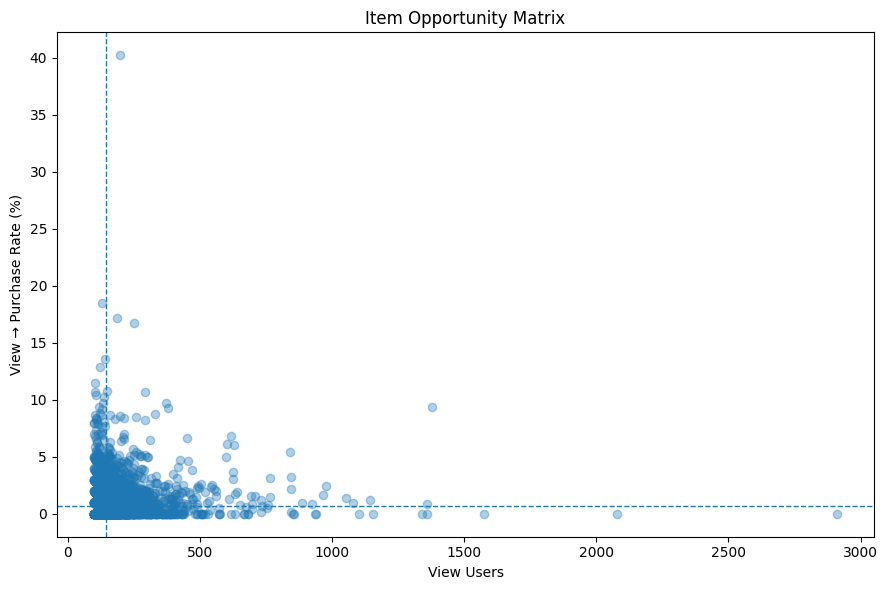

In [14]:
# ============================================================
# 13. Item Opportunity Matrix Chart
# ============================================================

sample_size = min(len(matrix_items), 5000)
plot_items = matrix_items.sample(sample_size, random_state=42)

plt.figure(figsize=(9, 6))
plt.scatter(
    plot_items["view_users"],
    plot_items["view_to_purchase_rate"] * 100,
    alpha=0.35,
)
plt.axvline(traffic_cutoff_item, linestyle="--", linewidth=1)
plt.axhline(conversion_cutoff_item * 100, linestyle="--", linewidth=1)
plt.title("Item Opportunity Matrix")
plt.xlabel("View Users")
plt.ylabel("View → Purchase Rate (%)")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()

save_chart("03_item_opportunity_matrix.png")
plt.show()

## 6. Category-Level Performance

카테고리 단위로 이벤트와 사용자 수를 집계한다.

카테고리 분석은 상품 단위보다 비즈니스 액션으로 연결하기 쉽다.

예를 들어 특정 카테고리에서 조회는 많지만 구매전환이 낮다면,
상세페이지 개선, 가격 정책, 상품 정렬, 추천 로직, 리뷰 노출 등의 A/B Test 후보가 된다.

In [15]:
# ============================================================
# 14. Category-Level Event Counts
# ============================================================

category_events = events_with_category.dropna(subset=["categoryid"]).copy()
category_events["categoryid"] = category_events["categoryid"].astype("int64")

category_event_counts = (
    category_events
    .pivot_table(
        index="categoryid",
        columns="event",
        values="visitorid",
        aggfunc="count",
        fill_value=0,
        observed=False,
    )
    .reset_index()
)

for col in ["view", "addtocart", "transaction"]:
    if col not in category_event_counts.columns:
        category_event_counts[col] = 0

category_event_counts = category_event_counts[["categoryid", "view", "addtocart", "transaction"]]

category_event_counts = category_event_counts.rename(columns={
    "view": "view_events",
    "addtocart": "cart_events",
    "transaction": "purchase_events",
})

category_unique_users = (
    category_events
    .groupby(["categoryid", "event"], observed=False)["visitorid"]
    .nunique()
    .reset_index(name="unique_visitors")
    .pivot(index="categoryid", columns="event", values="unique_visitors")
    .fillna(0)
    .reset_index()
)

for col in ["view", "addtocart", "transaction"]:
    if col not in category_unique_users.columns:
        category_unique_users[col] = 0

category_unique_users = category_unique_users[["categoryid", "view", "addtocart", "transaction"]]

category_unique_users = category_unique_users.rename(columns={
    "view": "view_users",
    "addtocart": "cart_users",
    "transaction": "purchase_users",
})

category_item_counts = (
    item_latest_category
    .groupby("categoryid", as_index=False)
    .agg(items_in_category=("itemid", "nunique"))
)

category_performance = category_event_counts.merge(
    category_unique_users,
    on="categoryid",
    how="left",
).merge(
    category_item_counts,
    on="categoryid",
    how="left",
)

if "parent_categoryid" in events_with_category.columns:
    category_parent = (
        events_with_category
        .dropna(subset=["categoryid"])
        .groupby("categoryid", as_index=False)
        .agg(parent_categoryid=("parent_categoryid", "first"))
    )
    category_performance = category_performance.merge(
        category_parent,
        on="categoryid",
        how="left",
    )

category_performance["view_to_cart_rate"] = safe_divide(
    category_performance["cart_users"],
    category_performance["view_users"],
)

category_performance["cart_to_purchase_rate"] = safe_divide(
    category_performance["purchase_users"],
    category_performance["cart_users"],
)

category_performance["view_to_purchase_rate"] = safe_divide(
    category_performance["purchase_users"],
    category_performance["view_users"],
)

category_performance["purchase_events_per_view_event"] = safe_divide(
    category_performance["purchase_events"],
    category_performance["view_events"],
)

category_performance["cart_events_per_view_event"] = safe_divide(
    category_performance["cart_events"],
    category_performance["view_events"],
)

category_performance = category_performance.sort_values(
    ["purchase_users", "view_to_purchase_rate", "view_users"],
    ascending=[False, False, False],
)

print("category_performance shape:", category_performance.shape)
display(category_performance.head(20))

save_table(category_performance, "03_category_performance_full.csv")

category_performance shape: (1086, 14)


,categoryid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,items_in_category,parent_categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
615,959,50112,1634,532,26897,1195,372,2603,"1,095.0000",0.0444,0.3113,0.0138,0.0106,0.0326
961,1483,62786,1525,469,40486,1163,341,3868,561.0000,0.0287,0.2932,0.0084,0.0075,0.0243
676,1051,73016,1715,485,35951,1252,312,3386,955.0000,0.0348,0.2492,0.0087,0.0066,0.0235
994,1542,12853,668,294,6724,486,249,1877,745.0000,0.0723,0.5123,0.0370,0.0229,0.0520
126,196,26646,744,298,16505,557,244,2365,"1,667.0000",0.0337,0.4381,0.0148,0.0112,0.0279
222,342,45288,1283,281,25935,965,232,17231,500.0000,0.0372,0.2404,0.0089,0.0062,0.0283
322,491,59300,1551,263,37763,1177,222,3373,679.0000,0.0312,0.1886,0.0059,0.0044,0.0262
746,1163,7157,374,259,3762,255,206,1099,561.0000,0.0678,0.8078,0.0548,0.0362,0.0523
407,618,14535,709,285,4806,480,203,2267,105.0000,0.0999,0.4229,0.0422,0.0196,0.0488
920,1421,9376,615,246,3510,396,196,2219,105.0000,0.1128,0.4949,0.0558,0.0262,0.0656


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_category_performance_full.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/03_category_performance_full.csv')

In [16]:
# ============================================================
# 15. Category-Level Summary Statistics
# ============================================================

category_performance_summary = (
    category_performance[
        [
            "items_in_category",
            "view_events",
            "cart_events",
            "purchase_events",
            "view_users",
            "cart_users",
            "purchase_users",
            "view_to_cart_rate",
            "cart_to_purchase_rate",
            "view_to_purchase_rate",
        ]
    ]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

display(category_performance_summary)
save_table(category_performance_summary, "03_category_performance_summary_stats.csv")

,metric,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
0,items_in_category,"1,086.0000",383.3840,"1,034.3258",1.0000,21.2500,95.5000,324.7500,848.5000,"1,596.2500","3,640.1000","17,231.0000"
1,view_events,"1,086.0000","2,219.1851","5,456.0846",1.0000,72.2500,477.0000,"2,132.7500","5,776.5000","9,394.0000","24,341.6500","73,016.0000"
2,cart_events,"1,086.0000",63.0746,153.0470,0.0000,0.0000,10.0000,55.0000,176.0000,299.5000,711.5500,"1,715.0000"
3,purchase_events,"1,086.0000",20.2413,46.9344,0.0000,0.0000,3.5000,16.7500,57.0000,94.7500,227.5000,532.0000
4,view_users,"1,086.0000","1,320.7523","3,086.5530",1.0000,53.2500,318.0000,"1,349.5000","3,606.5000","5,585.7500","13,532.7000","40,486.0000"
5,cart_users,"1,086.0000",46.4512,110.9479,0.0000,0.0000,8.5000,39.0000,129.5000,216.7500,489.7500,"1,252.0000"
6,purchase_users,"1,086.0000",16.7339,36.4187,0.0000,0.0000,3.0000,14.0000,49.0000,79.0000,183.1500,372.0000
7,view_to_cart_rate,"1,086.0000",0.0315,0.0383,0.0000,0.0000,0.0244,0.0450,0.0713,0.0931,0.1726,0.3636
8,cart_to_purchase_rate,760.0000,0.3888,0.2366,0.0000,0.2721,0.3750,0.5000,0.6250,0.7702,1.0000,2.0000
9,view_to_purchase_rate,"1,086.0000",0.0123,0.0186,0.0000,0.0000,0.0074,0.0174,0.0302,0.0417,0.0761,0.2727


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_category_performance_summary_stats.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/03_category_performance_summary_stats.csv')

In [17]:
# ============================================================
# 16. Top Categories by Traffic and Purchase
# ============================================================

top_categories_by_views = (
    category_performance
    .sort_values(["view_users", "view_events"], ascending=[False, False])
    .head(20)
)

top_categories_by_purchase = (
    category_performance
    .sort_values(["purchase_users", "purchase_events"], ascending=[False, False])
    .head(20)
)

top_categories_by_cart = (
    category_performance
    .sort_values(["cart_users", "cart_events"], ascending=[False, False])
    .head(20)
)

display(top_categories_by_views)
display(top_categories_by_cart)
display(top_categories_by_purchase)

save_table(top_categories_by_views, "03_top_categories_by_views.csv")
save_table(top_categories_by_cart, "03_top_categories_by_cart.csv")
save_table(top_categories_by_purchase, "03_top_categories_by_purchase.csv")

,categoryid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,items_in_category,parent_categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
961,1483,62786,1525,469,40486,1163,341,3868,561.0000,0.0287,0.2932,0.0084,0.0075,0.0243
322,491,59300,1551,263,37763,1177,222,3373,679.0000,0.0312,0.1886,0.0059,0.0044,0.0262
676,1051,73016,1715,485,35951,1252,312,3386,955.0000,0.0348,0.2492,0.0087,0.0066,0.0235
615,959,50112,1634,532,26897,1195,372,2603,"1,095.0000",0.0444,0.3113,0.0138,0.0106,0.0326
222,342,45288,1283,281,25935,965,232,17231,500.0000,0.0372,0.2404,0.0089,0.0062,0.0283
32,48,26705,603,146,17016,473,129,1558,500.0000,0.0278,0.2727,0.0076,0.0055,0.0226
126,196,26646,744,298,16505,557,244,2365,"1,667.0000",0.0337,0.4381,0.0148,0.0112,0.0279
445,683,37765,911,211,15924,683,184,1518,"1,606.0000",0.0429,0.2694,0.0116,0.0056,0.0241
823,1279,33532,726,123,15184,517,100,1635,"1,606.0000",0.0340,0.1934,0.0066,0.0037,0.0217
4,5,28953,577,186,15036,440,137,328,"1,637.0000",0.0293,0.3114,0.0091,0.0064,0.0199


,categoryid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,items_in_category,parent_categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
676,1051,73016,1715,485,35951,1252,312,3386,955.0000,0.0348,0.2492,0.0087,0.0066,0.0235
615,959,50112,1634,532,26897,1195,372,2603,"1,095.0000",0.0444,0.3113,0.0138,0.0106,0.0326
322,491,59300,1551,263,37763,1177,222,3373,679.0000,0.0312,0.1886,0.0059,0.0044,0.0262
961,1483,62786,1525,469,40486,1163,341,3868,561.0000,0.0287,0.2932,0.0084,0.0075,0.0243
222,342,45288,1283,281,25935,965,232,17231,500.0000,0.0372,0.2404,0.0089,0.0062,0.0283
445,683,37765,911,211,15924,683,184,1518,"1,606.0000",0.0429,0.2694,0.0116,0.0056,0.0241
126,196,26646,744,298,16505,557,244,2365,"1,667.0000",0.0337,0.4381,0.0148,0.0112,0.0279
732,1135,22921,746,208,10831,544,166,2116,"1,329.0000",0.0502,0.3051,0.0153,0.0091,0.0325
55,84,20936,762,222,9268,522,183,1556,"1,308.0000",0.0563,0.3506,0.0197,0.0106,0.0364
823,1279,33532,726,123,15184,517,100,1635,"1,606.0000",0.0340,0.1934,0.0066,0.0037,0.0217


,categoryid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,items_in_category,parent_categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
615,959,50112,1634,532,26897,1195,372,2603,"1,095.0000",0.0444,0.3113,0.0138,0.0106,0.0326
961,1483,62786,1525,469,40486,1163,341,3868,561.0000,0.0287,0.2932,0.0084,0.0075,0.0243
676,1051,73016,1715,485,35951,1252,312,3386,955.0000,0.0348,0.2492,0.0087,0.0066,0.0235
994,1542,12853,668,294,6724,486,249,1877,745.0000,0.0723,0.5123,0.0370,0.0229,0.0520
126,196,26646,744,298,16505,557,244,2365,"1,667.0000",0.0337,0.4381,0.0148,0.0112,0.0279
222,342,45288,1283,281,25935,965,232,17231,500.0000,0.0372,0.2404,0.0089,0.0062,0.0283
322,491,59300,1551,263,37763,1177,222,3373,679.0000,0.0312,0.1886,0.0059,0.0044,0.0262
746,1163,7157,374,259,3762,255,206,1099,561.0000,0.0678,0.8078,0.0548,0.0362,0.0523
407,618,14535,709,285,4806,480,203,2267,105.0000,0.0999,0.4229,0.0422,0.0196,0.0488
920,1421,9376,615,246,3510,396,196,2219,105.0000,0.1128,0.4949,0.0558,0.0262,0.0656


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_top_categories_by_views.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_top_categories_by_cart.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_top_categories_by_purchase.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/03_top_categories_by_purchase.csv')

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\03_top_categories_by_view_users.png


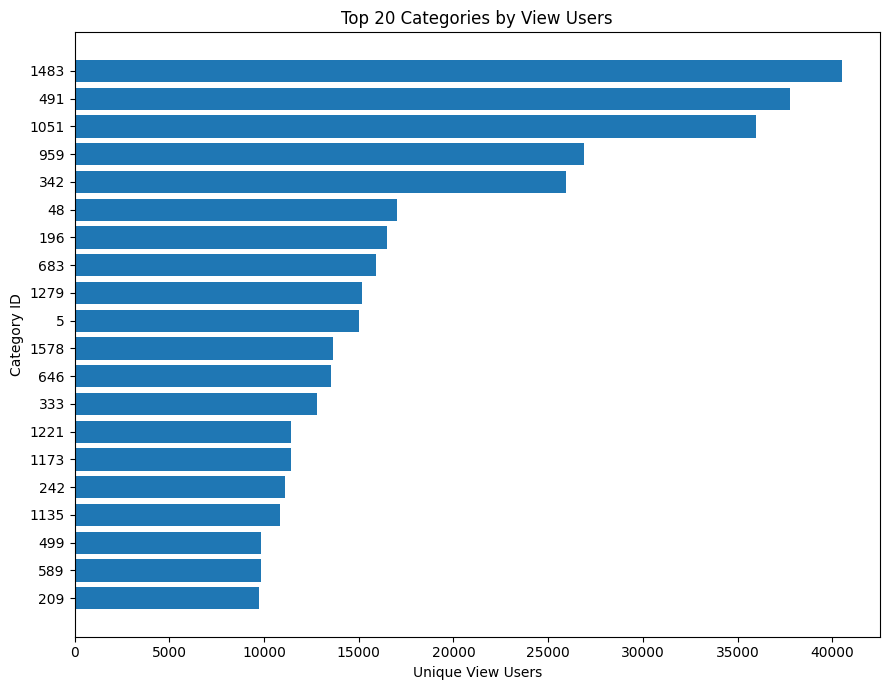

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\03_top_categories_by_purchase_users.png


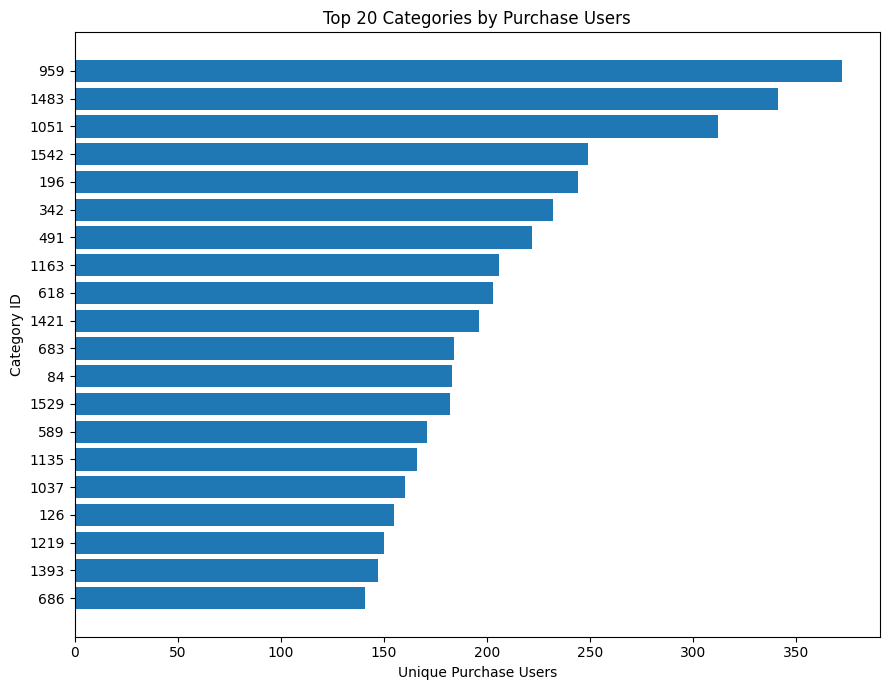

In [18]:
# ============================================================
# 17. Top Category Charts
# ============================================================

plot_df = top_categories_by_views.sort_values("view_users", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(plot_df["categoryid"].astype(str), plot_df["view_users"])
plt.title("Top 20 Categories by View Users")
plt.xlabel("Unique View Users")
plt.ylabel("Category ID")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()

save_chart("03_top_categories_by_view_users.png")
plt.show()


plot_df = top_categories_by_purchase.sort_values("purchase_users", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(plot_df["categoryid"].astype(str), plot_df["purchase_users"])
plt.title("Top 20 Categories by Purchase Users")
plt.xlabel("Unique Purchase Users")
plt.ylabel("Category ID")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()

save_chart("03_top_categories_by_purchase_users.png")
plt.show()

## 7. Category Conversion Quality

카테고리 전환율 역시 표본이 너무 작은 경우 과대평가될 수 있다.

따라서 최소 조회 사용자 수 기준을 적용한다.

- 기본 기준: category별 조회 사용자 500명 이상
- 필요하면 데이터 분포에 따라 조정 가능

In [19]:
# ============================================================
# 18. High-Conversion and Low-Conversion Categories
# ============================================================

min_view_users_category = 500

eligible_categories = category_performance.loc[
    category_performance["view_users"] >= min_view_users_category
].copy()

high_purchase_conversion_categories = (
    eligible_categories
    .sort_values(["view_to_purchase_rate", "purchase_users", "view_users"], ascending=[False, False, False])
    .head(30)
)

high_cart_conversion_categories = (
    eligible_categories
    .sort_values(["view_to_cart_rate", "cart_users", "view_users"], ascending=[False, False, False])
    .head(30)
)

traffic_threshold_category = eligible_categories["view_users"].quantile(0.90)
low_conversion_threshold_category = eligible_categories["view_to_purchase_rate"].quantile(0.25)

high_traffic_low_conversion_categories = (
    eligible_categories
    .loc[
        (eligible_categories["view_users"] >= traffic_threshold_category)
        & (eligible_categories["view_to_purchase_rate"] <= low_conversion_threshold_category)
    ]
    .sort_values(["view_users", "view_to_purchase_rate"], ascending=[False, True])
    .head(30)
)

display(high_purchase_conversion_categories)
display(high_cart_conversion_categories)
display(high_traffic_low_conversion_categories)

save_table(high_purchase_conversion_categories, "03_high_purchase_conversion_categories.csv")
save_table(high_cart_conversion_categories, "03_high_cart_conversion_categories.csv")
save_table(high_traffic_low_conversion_categories, "03_high_traffic_low_conversion_categories.csv")

,categoryid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,items_in_category,parent_categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
37,57,2229,128,150,922,83,71,89,314.0000,0.0900,0.8554,0.0770,0.0673,0.0574
270,417,1916,206,82,942,162,69,278,"1,215.0000",0.1720,0.4259,0.0732,0.0428,0.1075
666,1037,5190,658,226,2188,358,160,57,402.0000,0.1636,0.4469,0.0731,0.0435,0.1268
625,972,1975,164,74,1026,117,63,175,"1,249.0000",0.1140,0.5385,0.0614,0.0375,0.0830
920,1421,9376,615,246,3510,396,196,2219,105.0000,0.1128,0.4949,0.0558,0.0262,0.0656
746,1163,7157,374,259,3762,255,206,1099,561.0000,0.0678,0.8078,0.0548,0.0362,0.0523
411,624,5044,431,144,2266,243,124,1184,871.0000,0.1072,0.5103,0.0547,0.0285,0.0854
253,390,2548,116,67,1118,105,61,242,"1,546.0000",0.0939,0.5810,0.0546,0.0263,0.0455
884,1366,1185,77,35,711,62,35,274,"1,292.0000",0.0872,0.5645,0.0492,0.0295,0.0650
879,1359,906,63,27,550,57,26,341,"1,215.0000",0.1036,0.4561,0.0473,0.0298,0.0695


,categoryid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,items_in_category,parent_categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
270,417,1916,206,82,942,162,69,278,"1,215.0000",0.1720,0.4259,0.0732,0.0428,0.1075
281,434,4356,627,134,2423,398,83,520,968.0000,0.1643,0.2085,0.0343,0.0308,0.1439
666,1037,5190,658,226,2188,358,160,57,402.0000,0.1636,0.4469,0.0731,0.0435,0.1268
333,509,2428,201,41,1140,157,33,73,110.0000,0.1377,0.2102,0.0289,0.0169,0.0828
762,1191,2752,336,78,1714,233,68,580,61.0000,0.1359,0.2918,0.0397,0.0283,0.1221
625,972,1975,164,74,1026,117,63,175,"1,249.0000",0.1140,0.5385,0.0614,0.0375,0.0830
920,1421,9376,615,246,3510,396,196,2219,105.0000,0.1128,0.4949,0.0558,0.0262,0.0656
918,1418,921,90,17,536,60,14,401,896.0000,0.1119,0.2333,0.0261,0.0185,0.0977
411,624,5044,431,144,2266,243,124,1184,871.0000,0.1072,0.5103,0.0547,0.0285,0.0854
830,1286,1736,285,57,954,100,26,860,854.0000,0.1048,0.2600,0.0273,0.0328,0.1642


,categoryid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,items_in_category,parent_categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event
322,491,59300,1551,263,37763,1177,222,3373,679.0000,0.0312,0.1886,0.0059,0.0044,0.0262
426,646,27669,484,87,13512,349,68,2936,"1,606.0000",0.0258,0.1948,0.0050,0.0031,0.0175
328,499,13441,270,16,9843,216,15,873,986.0000,0.0219,0.0694,0.0015,0.0012,0.0201
278,429,12917,105,30,9645,92,29,1407,113.0000,0.0095,0.3152,0.0030,0.0023,0.0081
958,1477,13370,190,14,8253,143,12,1449,206.0000,0.0173,0.0839,0.0015,0.0010,0.0142
42,64,10568,250,22,7710,201,17,2501,206.0000,0.0261,0.0846,0.0022,0.0021,0.0237
634,984,11107,179,59,7629,136,45,1298,827.0000,0.0178,0.3309,0.0059,0.0053,0.0161
36,56,10925,185,38,6747,159,34,727,"1,497.0000",0.0236,0.2138,0.0050,0.0035,0.0169
751,1172,8662,101,32,6459,91,28,2847,810.0000,0.0141,0.3077,0.0043,0.0037,0.0117


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_high_purchase_conversion_categories.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_high_cart_conversion_categories.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_high_traffic_low_conversion_categories.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/03_high_traffic_low_conversion_categories.csv')

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\03_top_categories_by_purchase_conversion_rate.png


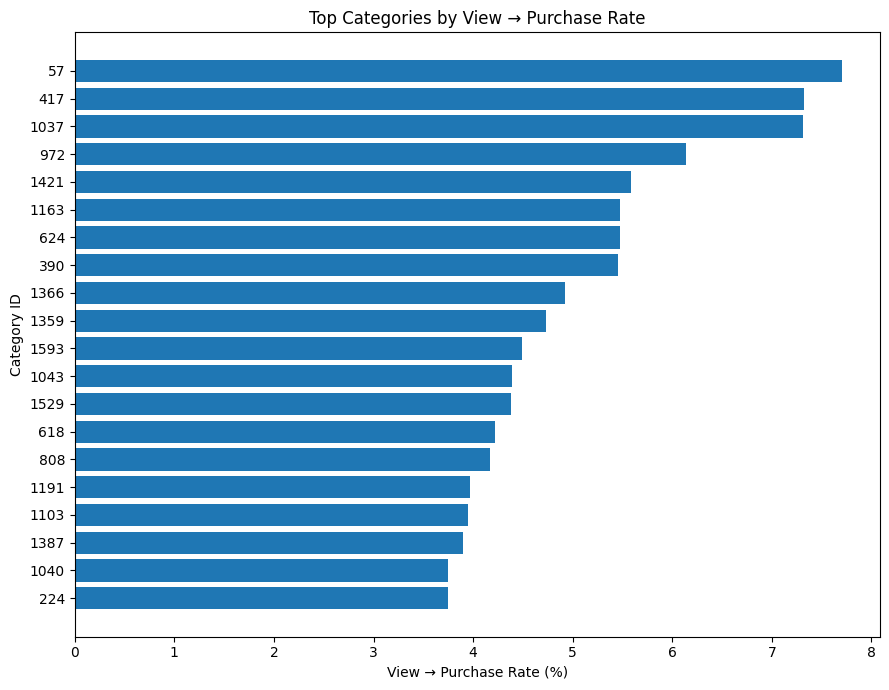

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\03_top_categories_by_cart_conversion_rate.png


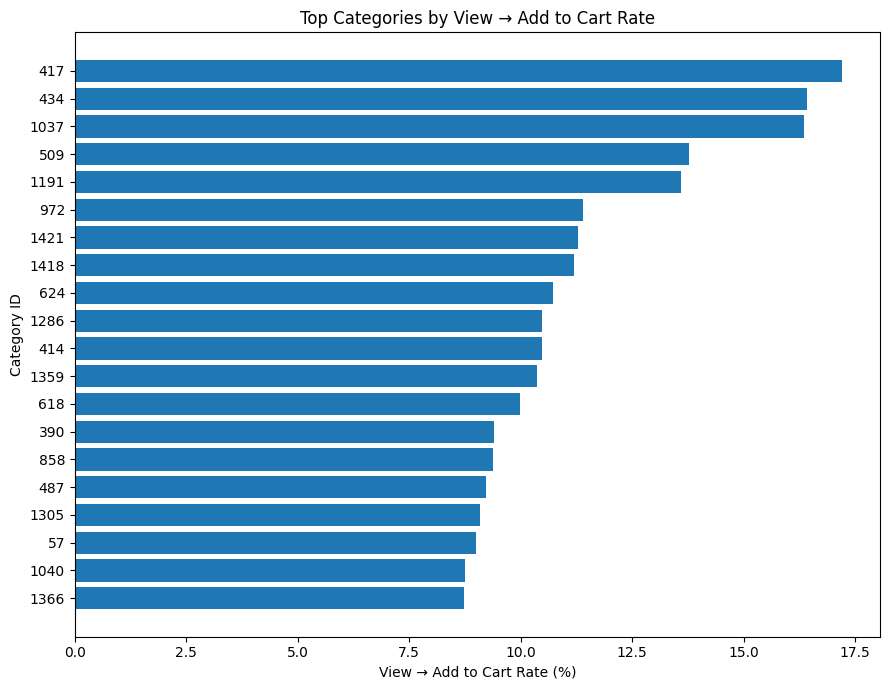

In [20]:
# ============================================================
# 19. Category Conversion Chart
# ============================================================

plot_df = high_purchase_conversion_categories.head(20).sort_values("view_to_purchase_rate", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(plot_df["categoryid"].astype(str), plot_df["view_to_purchase_rate"] * 100)
plt.title("Top Categories by View → Purchase Rate")
plt.xlabel("View → Purchase Rate (%)")
plt.ylabel("Category ID")
plt.tight_layout()

save_chart("03_top_categories_by_purchase_conversion_rate.png")
plt.show()


plot_df = high_cart_conversion_categories.head(20).sort_values("view_to_cart_rate", ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(plot_df["categoryid"].astype(str), plot_df["view_to_cart_rate"] * 100)
plt.title("Top Categories by View → Add to Cart Rate")
plt.xlabel("View → Add to Cart Rate (%)")
plt.ylabel("Category ID")
plt.tight_layout()

save_chart("03_top_categories_by_cart_conversion_rate.png")
plt.show()

## 8. Category Opportunity Matrix

카테고리를 조회량과 구매전환율 기준으로 4개 유형으로 분류한다.

상품 단위 matrix보다 더 비즈니스 액션에 가깝다.

- **Star Category**: 현재 성과가 높은 카테고리
- **Optimization Category**: 트래픽은 높지만 전환이 낮아 개선 우선순위가 높은 카테고리
- **Expansion Category**: 전환은 높지만 노출이 부족해 추천/프로모션 확대 후보
- **Long-tail Category**: 단기 우선순위 낮음

In [21]:
# ============================================================
# 20. Category Opportunity Matrix
# ============================================================

matrix_categories = category_performance.loc[
    category_performance["view_users"] >= min_view_users_category
].copy()

traffic_cutoff_category = matrix_categories["view_users"].median()
conversion_cutoff_category = matrix_categories["view_to_purchase_rate"].median()

matrix_categories["traffic_level"] = np.where(
    matrix_categories["view_users"] >= traffic_cutoff_category,
    "High traffic",
    "Low traffic",
)

matrix_categories["conversion_level"] = np.where(
    matrix_categories["view_to_purchase_rate"] >= conversion_cutoff_category,
    "High conversion",
    "Low conversion",
)

matrix_categories["opportunity_type"] = matrix_categories.apply(classify_opportunity, axis=1)

category_opportunity_summary = (
    matrix_categories
    .groupby("opportunity_type", as_index=False)
    .agg(
        categories=("categoryid", "nunique"),
        total_items=("items_in_category", "sum"),
        total_view_users=("view_users", "sum"),
        total_cart_users=("cart_users", "sum"),
        total_purchase_users=("purchase_users", "sum"),
        avg_view_to_cart_rate=("view_to_cart_rate", "mean"),
        avg_view_to_purchase_rate=("view_to_purchase_rate", "mean"),
        median_view_users=("view_users", "median"),
    )
)

category_opportunity_summary["overall_view_to_cart_rate"] = (
    category_opportunity_summary["total_cart_users"] / category_opportunity_summary["total_view_users"]
)

category_opportunity_summary["overall_view_to_purchase_rate"] = (
    category_opportunity_summary["total_purchase_users"] / category_opportunity_summary["total_view_users"]
)

display(category_opportunity_summary)

save_table(matrix_categories, "03_category_opportunity_matrix_full.csv")
save_table(category_opportunity_summary, "03_category_opportunity_summary.csv")

,opportunity_type,categories,total_items,total_view_users,total_cart_users,total_purchase_users,avg_view_to_cart_rate,avg_view_to_purchase_rate,median_view_users,overall_view_to_cart_rate,overall_view_to_purchase_rate
0,Expansion: low traffic & high conversion,119,41331,116589,6141,2677,0.0533,0.0231,954.0000,0.0527,0.0230
1,Long-tail: low traffic & low conversion,110,38781,106872,2014,613,0.0188,0.0056,863.5000,0.0188,0.0057
2,Optimization: high traffic & low conversion,119,166048,673232,16847,4606,0.0216,0.0062,"3,286.0000",0.0250,0.0068
3,Star: high traffic & high conversion,111,101525,455546,22697,9193,0.0531,0.0220,"3,482.0000",0.0498,0.0202


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_category_opportunity_matrix_full.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_category_opportunity_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/03_category_opportunity_summary.csv')

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\03_category_opportunity_matrix.png


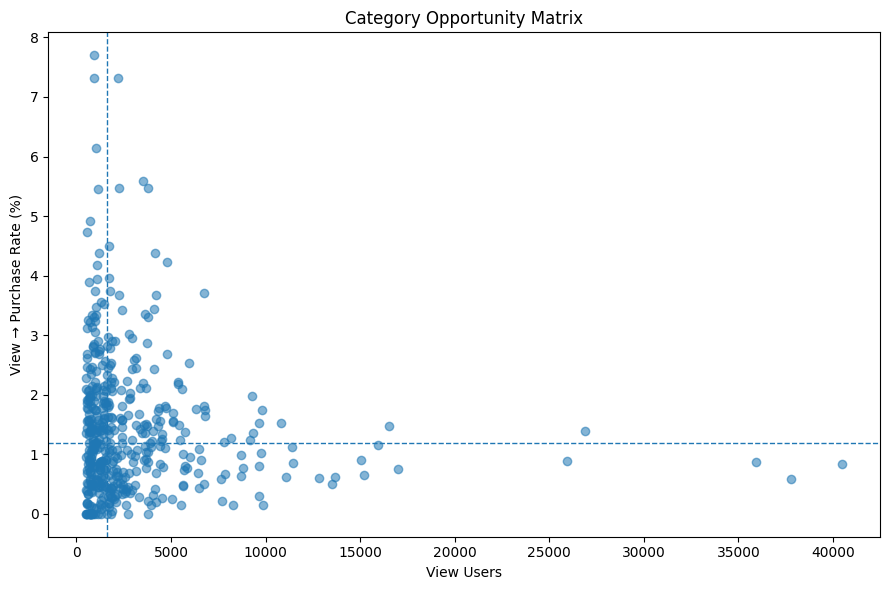

In [22]:
# ============================================================
# 21. Category Opportunity Matrix Chart
# ============================================================

plt.figure(figsize=(9, 6))
plt.scatter(
    matrix_categories["view_users"],
    matrix_categories["view_to_purchase_rate"] * 100,
    alpha=0.55,
)
plt.axvline(traffic_cutoff_category, linestyle="--", linewidth=1)
plt.axhline(conversion_cutoff_category * 100, linestyle="--", linewidth=1)
plt.title("Category Opportunity Matrix")
plt.xlabel("View Users")
plt.ylabel("View → Purchase Rate (%)")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()

save_chart("03_category_opportunity_matrix.png")
plt.show()

## 9. A/B Test Candidate Extraction

이 단계에서는 이후 실험 설계로 연결할 후보군을 만든다.

### 1. Optimization Candidate

조회는 많지만 구매전환율이 낮은 카테고리이다.

실험 아이디어:
- 상품 상세페이지 CTA 개선
- 가격/배송/혜택 정보 위치 개선
- 리뷰/평점 노출 강화
- 추천 상품 영역 개선
- 장바구니 담기 버튼 문구 변경

### 2. Expansion Candidate

조회는 낮지만 구매전환율이 높은 카테고리이다.

실험 아이디어:
- 홈/추천 영역 노출 확대
- 검색 결과 상단 노출
- 유사 상품 추천 강화
- 프로모션 배너 테스트

In [23]:
# ============================================================
# 22. A/B Test Candidate Categories
# ============================================================

optimization_candidate_categories = (
    matrix_categories
    .loc[matrix_categories["opportunity_type"] == "Optimization: high traffic & low conversion"]
    .sort_values(["view_users", "view_to_purchase_rate"], ascending=[False, True])
    .head(20)
)

expansion_candidate_categories = (
    matrix_categories
    .loc[matrix_categories["opportunity_type"] == "Expansion: low traffic & high conversion"]
    .sort_values(["view_to_purchase_rate", "purchase_users"], ascending=[False, False])
    .head(20)
)

star_categories = (
    matrix_categories
    .loc[matrix_categories["opportunity_type"] == "Star: high traffic & high conversion"]
    .sort_values(["purchase_users", "view_to_purchase_rate"], ascending=[False, False])
    .head(20)
)

display(optimization_candidate_categories)
display(expansion_candidate_categories)
display(star_categories)

save_table(optimization_candidate_categories, "03_abtest_optimization_candidate_categories.csv")
save_table(expansion_candidate_categories, "03_abtest_expansion_candidate_categories.csv")
save_table(star_categories, "03_star_categories.csv")

,categoryid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,items_in_category,parent_categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event,traffic_level,conversion_level,opportunity_type
961,1483,62786,1525,469,40486,1163,341,3868,561.0000,0.0287,0.2932,0.0084,0.0075,0.0243,High traffic,Low conversion,Optimization: high traffic & low conversion
322,491,59300,1551,263,37763,1177,222,3373,679.0000,0.0312,0.1886,0.0059,0.0044,0.0262,High traffic,Low conversion,Optimization: high traffic & low conversion
676,1051,73016,1715,485,35951,1252,312,3386,955.0000,0.0348,0.2492,0.0087,0.0066,0.0235,High traffic,Low conversion,Optimization: high traffic & low conversion
222,342,45288,1283,281,25935,965,232,17231,500.0000,0.0372,0.2404,0.0089,0.0062,0.0283,High traffic,Low conversion,Optimization: high traffic & low conversion
32,48,26705,603,146,17016,473,129,1558,500.0000,0.0278,0.2727,0.0076,0.0055,0.0226,High traffic,Low conversion,Optimization: high traffic & low conversion
445,683,37765,911,211,15924,683,184,1518,"1,606.0000",0.0429,0.2694,0.0116,0.0056,0.0241,High traffic,Low conversion,Optimization: high traffic & low conversion
823,1279,33532,726,123,15184,517,100,1635,"1,606.0000",0.0340,0.1934,0.0066,0.0037,0.0217,High traffic,Low conversion,Optimization: high traffic & low conversion
4,5,28953,577,186,15036,440,137,328,"1,637.0000",0.0293,0.3114,0.0091,0.0064,0.0199,High traffic,Low conversion,Optimization: high traffic & low conversion
1019,1578,21494,583,105,13650,292,84,1236,"1,249.0000",0.0214,0.2877,0.0062,0.0049,0.0271,High traffic,Low conversion,Optimization: high traffic & low conversion
426,646,27669,484,87,13512,349,68,2936,"1,606.0000",0.0258,0.1948,0.0050,0.0031,0.0175,High traffic,Low conversion,Optimization: high traffic & low conversion


,categoryid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,items_in_category,parent_categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event,traffic_level,conversion_level,opportunity_type
37,57,2229,128,150,922,83,71,89,314.0000,0.0900,0.8554,0.0770,0.0673,0.0574,Low traffic,High conversion,Expansion: low traffic & high conversion
270,417,1916,206,82,942,162,69,278,"1,215.0000",0.1720,0.4259,0.0732,0.0428,0.1075,Low traffic,High conversion,Expansion: low traffic & high conversion
625,972,1975,164,74,1026,117,63,175,"1,249.0000",0.1140,0.5385,0.0614,0.0375,0.0830,Low traffic,High conversion,Expansion: low traffic & high conversion
253,390,2548,116,67,1118,105,61,242,"1,546.0000",0.0939,0.5810,0.0546,0.0263,0.0455,Low traffic,High conversion,Expansion: low traffic & high conversion
884,1366,1185,77,35,711,62,35,274,"1,292.0000",0.0872,0.5645,0.0492,0.0295,0.0650,Low traffic,High conversion,Expansion: low traffic & high conversion
879,1359,906,63,27,550,57,26,341,"1,215.0000",0.1036,0.4561,0.0473,0.0298,0.0695,Low traffic,High conversion,Expansion: low traffic & high conversion
670,1043,1893,67,63,1208,49,53,400,226.0000,0.0406,1.0816,0.0439,0.0333,0.0354,Low traffic,High conversion,Expansion: low traffic & high conversion
527,808,2314,102,61,1103,78,46,219,"1,272.0000",0.0707,0.5897,0.0417,0.0264,0.0441,Low traffic,High conversion,Expansion: low traffic & high conversion
710,1103,1653,78,44,1064,69,42,115,"1,368.0000",0.0648,0.6087,0.0395,0.0266,0.0472,Low traffic,High conversion,Expansion: low traffic & high conversion
896,1387,1238,47,28,642,42,25,386,933.0000,0.0654,0.5952,0.0389,0.0226,0.0380,Low traffic,High conversion,Expansion: low traffic & high conversion


,categoryid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,items_in_category,parent_categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event,traffic_level,conversion_level,opportunity_type
615,959,50112,1634,532,26897,1195,372,2603,"1,095.0000",0.0444,0.3113,0.0138,0.0106,0.0326,High traffic,High conversion,Star: high traffic & high conversion
994,1542,12853,668,294,6724,486,249,1877,745.0000,0.0723,0.5123,0.0370,0.0229,0.0520,High traffic,High conversion,Star: high traffic & high conversion
126,196,26646,744,298,16505,557,244,2365,"1,667.0000",0.0337,0.4381,0.0148,0.0112,0.0279,High traffic,High conversion,Star: high traffic & high conversion
746,1163,7157,374,259,3762,255,206,1099,561.0000,0.0678,0.8078,0.0548,0.0362,0.0523,High traffic,High conversion,Star: high traffic & high conversion
407,618,14535,709,285,4806,480,203,2267,105.0000,0.0999,0.4229,0.0422,0.0196,0.0488,High traffic,High conversion,Star: high traffic & high conversion
920,1421,9376,615,246,3510,396,196,2219,105.0000,0.1128,0.4949,0.0558,0.0262,0.0656,High traffic,High conversion,Star: high traffic & high conversion
55,84,20936,762,222,9268,522,183,1556,"1,308.0000",0.0563,0.3506,0.0197,0.0106,0.0364,High traffic,High conversion,Star: high traffic & high conversion
987,1529,9174,432,221,4154,335,182,183,805.0000,0.0806,0.5433,0.0438,0.0241,0.0471,High traffic,High conversion,Star: high traffic & high conversion
389,589,20473,672,209,9835,511,171,1205,"1,308.0000",0.0520,0.3346,0.0174,0.0102,0.0328,High traffic,High conversion,Star: high traffic & high conversion
732,1135,22921,746,208,10831,544,166,2116,"1,329.0000",0.0502,0.3051,0.0153,0.0091,0.0325,High traffic,High conversion,Star: high traffic & high conversion


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_abtest_optimization_candidate_categories.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_abtest_expansion_candidate_categories.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_star_categories.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/03_star_categories.csv')

In [24]:
# ============================================================
# 23. A/B Test Candidate Items
# ============================================================

optimization_candidate_items = (
    matrix_items
    .loc[matrix_items["opportunity_type"] == "Optimization: high traffic & low conversion"]
    .sort_values(["view_users", "view_to_purchase_rate"], ascending=[False, True])
    .head(30)
)

expansion_candidate_items = (
    matrix_items
    .loc[matrix_items["opportunity_type"] == "Expansion: low traffic & high conversion"]
    .sort_values(["view_to_purchase_rate", "purchase_users"], ascending=[False, False])
    .head(30)
)

star_items = (
    matrix_items
    .loc[matrix_items["opportunity_type"] == "Star: high traffic & high conversion"]
    .sort_values(["purchase_users", "view_to_purchase_rate"], ascending=[False, False])
    .head(30)
)

display(optimization_candidate_items)
display(expansion_candidate_items)
display(star_items)

save_table(optimization_candidate_items, "03_abtest_optimization_candidate_items.csv")
save_table(expansion_candidate_items, "03_abtest_expansion_candidate_items.csv")
save_table(star_items, "03_star_items.csv")

,itemid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event,traffic_level,conversion_level,opportunity_type
94720,187946,3410,2,0,2911,2,0,"1,393.0000",0.0007,0.0000,0.0000,0.0000,0.0006,High traffic,Low conversion,Optimization: high traffic & low conversion
2719,5411,2325,9,0,2078,9,0,789.0000,0.0043,0.0000,0.0000,0.0000,0.0039,High traffic,Low conversion,Optimization: high traffic & low conversion
186716,370653,1854,0,0,1577,0,0,82.0000,0.0000,NaN,0.0000,0.0000,0.0000,High traffic,Low conversion,Optimization: high traffic & low conversion
49024,96924,1633,0,0,1359,0,0,56.0000,0.0000,NaN,0.0000,0.0000,0.0000,High traffic,Low conversion,Optimization: high traffic & low conversion
150148,298009,1642,0,0,1342,0,0,529.0000,0.0000,NaN,0.0000,0.0000,0.0000,High traffic,Low conversion,Optimization: high traffic & low conversion
169261,335975,1428,0,0,1154,0,0,48.0000,0.0000,NaN,0.0000,0.0000,0.0000,High traffic,Low conversion,Optimization: high traffic & low conversion
76432,151444,1230,0,0,1103,0,0,656.0000,0.0000,NaN,0.0000,0.0000,0.0000,High traffic,Low conversion,Optimization: high traffic & low conversion
218935,434782,1069,0,0,938,0,0,239.0000,0.0000,NaN,0.0000,0.0000,0.0000,High traffic,Low conversion,Optimization: high traffic & low conversion
71944,142466,1135,1,0,936,1,0,"1,375.0000",0.0011,0.0000,0.0000,0.0000,0.0009,High traffic,Low conversion,Optimization: high traffic & low conversion
51710,102306,1013,0,0,858,0,0,499.0000,0.0000,NaN,0.0000,0.0000,0.0000,High traffic,Low conversion,Optimization: high traffic & low conversion


,itemid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event,traffic_level,conversion_level,opportunity_type
168412,334401,200,8,28,130,7,24,"1,043.0000",0.0538,3.4286,0.1846,0.1400,0.0400,Low traffic,High conversion,Expansion: low traffic & high conversion
109584,217605,232,23,19,140,22,19,972.0000,0.1571,0.8636,0.1357,0.0819,0.0991,Low traffic,High conversion,Expansion: low traffic & high conversion
46766,92466,181,30,16,124,28,16,417.0000,0.2258,0.5714,0.1290,0.0884,0.1657,Low traffic,High conversion,Expansion: low traffic & high conversion
40924,80858,177,25,12,105,24,12,"1,558.0000",0.2286,0.5000,0.1143,0.0678,0.1412,Low traffic,High conversion,Expansion: low traffic & high conversion
87904,174489,146,24,13,103,21,11,224.0000,0.2039,0.5238,0.1068,0.0890,0.1644,Low traffic,High conversion,Expansion: low traffic & high conversion
94076,186702,162,11,12,106,10,11,57.0000,0.0943,1.1000,0.1038,0.0741,0.0679,Low traffic,High conversion,Expansion: low traffic & high conversion
176573,350384,233,29,14,137,27,14,"1,642.0000",0.1971,0.5185,0.1022,0.0601,0.1245,Low traffic,High conversion,Expansion: low traffic & high conversion
231918,460553,194,18,13,134,15,13,"1,529.0000",0.1119,0.8667,0.0970,0.0670,0.0928,Low traffic,High conversion,Expansion: low traffic & high conversion
8209,16344,204,29,11,118,25,11,1.0000,0.2119,0.4400,0.0932,0.0539,0.1422,Low traffic,High conversion,Expansion: low traffic & high conversion
163302,324290,238,20,12,131,19,12,"1,593.0000",0.1450,0.6316,0.0916,0.0504,0.0840,Low traffic,High conversion,Expansion: low traffic & high conversion


,itemid,view_events,cart_events,purchase_events,view_users,cart_users,purchase_users,categoryid,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events_per_view_event,cart_events_per_view_event,traffic_level,conversion_level,opportunity_type
232496,461686,2539,306,133,1379,267,129,"1,037.0000",0.1936,0.4831,0.0935,0.0524,0.1205,High traffic,High conversion,Star: high traffic & high conversion
107690,213834,293,17,92,199,17,80,"1,163.0000",0.0854,4.7059,0.4020,0.3140,0.0580,High traffic,High conversion,Star: high traffic & high conversion
3980,7943,1346,97,46,843,87,46,398.0000,0.1032,0.5287,0.0546,0.0342,0.0721,High traffic,High conversion,Star: high traffic & high conversion
60527,119736,752,44,97,251,30,42,57.0000,0.1195,1.4000,0.1673,0.1290,0.0585,High traffic,High conversion,Star: high traffic & high conversion
224330,445351,939,89,45,618,80,42,"1,483.0000",0.1294,0.5250,0.0680,0.0479,0.0948,High traffic,High conversion,Star: high traffic & high conversion
24339,48030,986,95,41,628,85,38,"1,219.0000",0.1354,0.4471,0.0605,0.0416,0.0963,High traffic,High conversion,Star: high traffic & high conversion
157492,312728,947,162,46,602,129,37,"1,098.0000",0.2143,0.2868,0.0615,0.0486,0.1711,High traffic,High conversion,Star: high traffic & high conversion
212061,420960,796,60,38,371,55,36,"1,529.0000",0.1482,0.6545,0.0970,0.0477,0.0754,High traffic,High conversion,Star: high traffic & high conversion
8763,17478,631,72,37,378,65,35,"1,373.0000",0.1720,0.5385,0.0926,0.0586,0.1141,High traffic,High conversion,Star: high traffic & high conversion
209597,416017,393,49,32,186,45,32,"1,103.0000",0.2419,0.7111,0.1720,0.0814,0.1247,High traffic,High conversion,Star: high traffic & high conversion


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_abtest_optimization_candidate_items.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_abtest_expansion_candidate_items.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_star_items.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/03_star_items.csv')

## 10. Final Business Interpretation

마지막으로 상품/카테고리 분석 결과를 비즈니스 의사결정 언어로 정리한다.

이 표는 README, WikiDocs, Streamlit, 발표자료에 그대로 활용할 수 있다.

In [25]:
# ============================================================
# 24. Final Business Insight Summary
# ============================================================

top_purchase_category = top_categories_by_purchase.iloc[0]
top_view_category = top_categories_by_views.iloc[0]

if len(optimization_candidate_categories) > 0:
    top_optimization_category = optimization_candidate_categories.iloc[0]
    optimization_text = (
        f"Category {int(top_optimization_category['categoryid'])} has high traffic "
        f"({int(top_optimization_category['view_users']):,} view users) but relatively low purchase conversion "
        f"({top_optimization_category['view_to_purchase_rate'] * 100:.2f}%)."
    )
else:
    optimization_text = "No clear high-traffic low-conversion category was detected under the current threshold."

if len(expansion_candidate_categories) > 0:
    top_expansion_category = expansion_candidate_categories.iloc[0]
    expansion_text = (
        f"Category {int(top_expansion_category['categoryid'])} shows strong purchase conversion "
        f"({top_expansion_category['view_to_purchase_rate'] * 100:.2f}%) despite relatively lower traffic."
    )
else:
    expansion_text = "No clear low-traffic high-conversion category was detected under the current threshold."

business_insight_summary = pd.DataFrame([
    {
        "insight_area": "Top purchase category",
        "finding": (
            f"Category {int(top_purchase_category['categoryid'])} generated the highest number of purchase users "
            f"({int(top_purchase_category['purchase_users']):,})."
        ),
        "business_action": "Maintain exposure and use as a benchmark for high-performing categories.",
    },
    {
        "insight_area": "Top traffic category",
        "finding": (
            f"Category {int(top_view_category['categoryid'])} generated the highest number of view users "
            f"({int(top_view_category['view_users']):,})."
        ),
        "business_action": "Monitor whether high traffic is efficiently converted into cart and purchase actions.",
    },
    {
        "insight_area": "Optimization opportunity",
        "finding": optimization_text,
        "business_action": "Prioritize A/B tests on product detail UX, CTA placement, benefit messaging, and recommendation modules.",
    },
    {
        "insight_area": "Expansion opportunity",
        "finding": expansion_text,
        "business_action": "Consider increasing exposure through recommendation slots, search ranking, or promotional placements.",
    },
    {
        "insight_area": "A/B Test primary metric",
        "finding": "The item/category analysis supports View → Add to Cart as a practical primary metric for product-page experiments.",
        "business_action": "Use View → Add to Cart conversion as the primary metric and View → Purchase as the downstream guardrail metric.",
    },
])

display(business_insight_summary)
save_table(business_insight_summary, "03_business_insight_summary.csv")

,insight_area,finding,business_action
0,Top purchase category,Category 959 generated the highest number of p...,Maintain exposure and use as a benchmark for h...
1,Top traffic category,Category 1483 generated the highest number of ...,Monitor whether high traffic is efficiently co...
2,Optimization opportunity,"Category 1483 has high traffic (40,486 view us...","Prioritize A/B tests on product detail UX, CTA..."
3,Expansion opportunity,Category 57 shows strong purchase conversion (...,Consider increasing exposure through recommend...
4,A/B Test primary metric,The item/category analysis supports View → Add...,Use View → Add to Cart conversion as the prima...


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\03_business_insight_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/03_business_insight_summary.csv')

In [26]:
# ============================================================
# 25. Save Compact Datasets for Streamlit
# ============================================================

# Streamlit에서 빠르게 로드할 수 있도록 핵심 집계 테이블을 processed에도 저장한다.
streamlit_tables = {
    "item_performance.parquet": item_performance,
    "category_performance.parquet": category_performance,
    "item_opportunity_summary.parquet": item_opportunity_summary,
    "category_opportunity_summary.parquet": category_opportunity_summary,
    "business_insight_summary.parquet": business_insight_summary,
}

for filename, df in streamlit_tables.items():
    save_path = PROCESSED_DIR / filename
    try:
        df.to_parquet(save_path, index=False)
        print(f"saved: {save_path}")
    except Exception as e:
        print(f"parquet save failed for {filename}: {e}")

print("03_item_category_analysis completed.")
print("Next notebook: 04_ab_test_design_simulation.ipynb")

parquet save failed for item_performance.parquet: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.
parquet save failed for category_performance.parquet: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install f